# Manifest and cohort exploration

Manifest integrity, image geometry, and tumor-region burden summaries used before model training.

In [1]:
from pathlib import Path
import os
import sys
from functools import partial

_start = Path(os.environ.get("BRATS_PROJECT_ROOT", Path.cwd())).expanduser().resolve()
PROJECT_ROOT = next(
    (p for p in (_start, *_start.parents) if (p / "src" / "brats_pipeline").is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Place notebooks/ and src/ under one project root, or set BRATS_PROJECT_ROOT.")
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))
os.chdir(PROJECT_ROOT)
from brats_pipeline.common import ProjectPaths
paths_io = ProjectPaths(PROJECT_ROOT)
resolve_existing_path = paths_io.resolve
print("Project:", PROJECT_ROOT)

Project: /home/mandrakedrink/projects/research_ts_bs


In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

import nibabel as nib
from brats_pipeline.data import jp
MANIFEST_PATH = PROJECT_ROOT / "data/processed/manifest_4clients_seed42.csv"
FIG_DIR = PROJECT_ROOT / "docs/figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
MODALITIES = ["t1", "t1ce", "t2", "flair", "seg"]

## Manifest overview

In [3]:
mf_df = pd.read_csv(MANIFEST_PATH)

print("shape:", mf_df.shape)
mf_df.head()

shape: (1060, 4)


,patient_id,paths,client_domain,split
0,BraTS2021_00000,"{""t1"": ""/home/mandrakedrink/projects/research_...",UCSF-PDGM,val
1,BraTS2021_00002,"{""t1"": ""/home/mandrakedrink/projects/research_...",UCSF-PDGM,train
2,BraTS2021_00003,"{""t1"": ""/home/mandrakedrink/projects/research_...",UCSF-PDGM,test
3,BraTS2021_00005,"{""t1"": ""/home/mandrakedrink/projects/research_...",UCSF-PDGM,train
4,BraTS2021_00006,"{""t1"": ""/home/mandrakedrink/projects/research_...",UCSF-PDGM,train


In [4]:
mf_df.isna().sum()

patient_id       0
paths            0
client_domain    0
split            0
dtype: int64

In [5]:
mf_df["client_domain"].value_counts()

client_domain
UPENN-GBM    511
UCSF-PDGM    382
TCGA-GBM     102
TCGA-LGG      65
Name: count, dtype: int64

In [6]:
mf_df["split"].value_counts()

split
train    744
test     211
val      105
Name: count, dtype: int64

## File availability

In [7]:
def paths_exist(value):
    mapping = jp(value)
    return {name: paths_io.resolve(mapping.get(name), required=False) is not None
            for name in MODALITIES}

In [8]:
ex = mf_df["paths"].apply(paths_exist)

ex_df = pd.DataFrame(list(ex))
ex_df.head()

,t1,t1ce,t2,flair,seg
0,True,True,True,True,True
1,True,True,True,True,True
2,True,True,True,True,True
3,True,True,True,True,True
4,True,True,True,True,True


In [9]:
ex_df.all()

t1       True
t1ce     True
t2       True
flair    True
seg      True
dtype: bool

In [10]:
bad = ex_df[~ex_df.all(axis=1)]
print("bad rows:", len(bad))

bad rows: 0


## One-case inspection

In [11]:
r = mf_df.iloc[0]
p = jp(r["paths"])

print(r["patient_id"])
print(r["client_domain"])
print(r["split"])
p

def load_nii(path):
    return nib.load(str(paths_io.resolve(path))).get_fdata()

BraTS2021_00000
UCSF-PDGM
val


In [12]:
t1 = load_nii(p["t1"])
t1ce = load_nii(p["t1ce"])
t2 = load_nii(p["t2"])
flair = load_nii(p["flair"])
seg = load_nii(p["seg"])

t1.shape, t1ce.shape, t2.shape, flair.shape, seg.shape

def best_slice(mask):
    return int(np.argmax((mask > 0).sum(axis=(0, 1))))

In [13]:
np.unique(seg)

array([0., 1., 2., 4.])

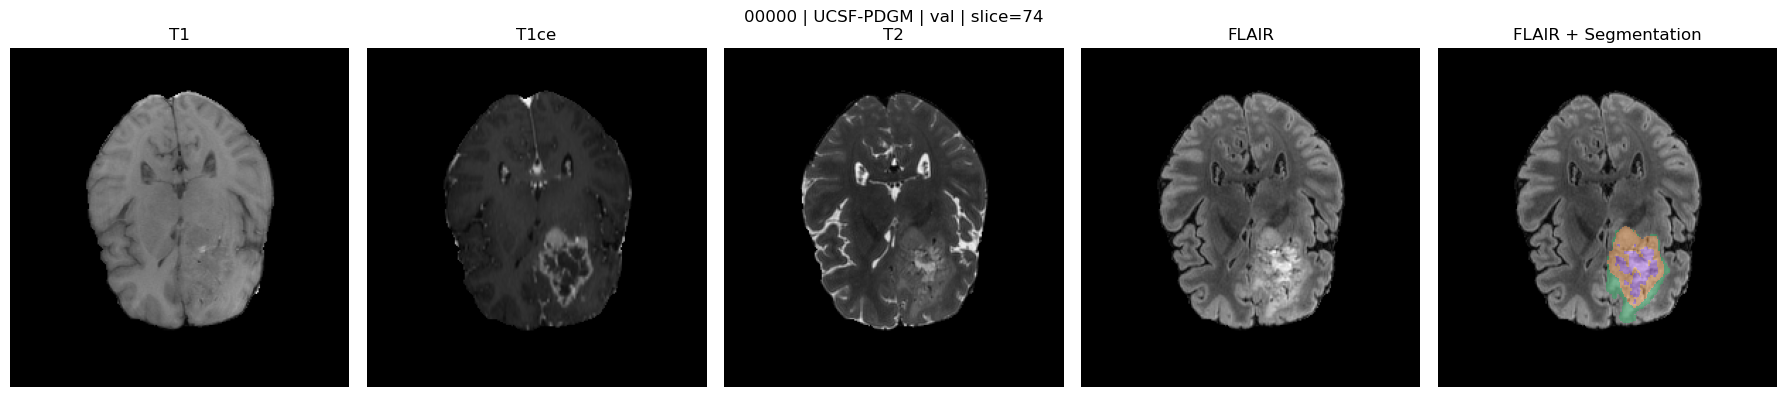

In [14]:
SEG_CMAP = ListedColormap([
    "#9B51E0",  # class 1
    "#27AE60",  # class 2
    "#F2994A",  # class 3
])

SEG_NORM = BoundaryNorm(
    [0.5, 1.5, 2.5, 3.5],
    SEG_CMAP.N
)

z = best_slice(seg)

fig, ax = plt.subplots(1, 5, figsize=(18, 4))

ax[0].imshow(t1[:, :, z].T, cmap="gray", origin="lower")
ax[0].set_title("T1")

ax[1].imshow(t1ce[:, :, z].T, cmap="gray", origin="lower")
ax[1].set_title("T1ce")

ax[2].imshow(t2[:, :, z].T, cmap="gray", origin="lower")
ax[2].set_title("T2")

ax[3].imshow(flair[:, :, z].T, cmap="gray", origin="lower")
ax[3].set_title("FLAIR")

ax[4].imshow(flair[:, :, z].T, cmap="gray", origin="lower")

seg_slice = seg[:, :, z].T
seg_overlay = np.ma.masked_equal(seg_slice, 0)

ax[4].imshow(
    seg_overlay,
    cmap=SEG_CMAP,
    norm=SEG_NORM,
    alpha=0.45,
    origin="lower",
    interpolation="nearest",
)
ax[4].set_title("FLAIR + Segmentation")

for a in ax:
    a.axis("off")

plt.suptitle(
    f"{r['patient_id'].split('_')[-1]} | {r['client_domain']} | {r['split']} | slice={z}"
)
plt.tight_layout()
plt.show()

## Array geometry

In [15]:
def get_shapes(row):
    """Read the shape of each modality and the label volume."""
    d = jp(row["paths"])
    out = {}
    for m in MODALITIES:
        out[m] = nib.load(str(paths_io.resolve(d[m]))).shape
    return out

In [16]:
shape_rows = []

for i in range(min(20, len(mf_df))):
    r = mf_df.iloc[i]
    sh = get_shapes(r)
    shape_rows.append({
        "patient_id": r["patient_id"],
        "client_domain": r["client_domain"],
        "split": r["split"],
        **sh
    })

sdf = pd.DataFrame(shape_rows)
sdf.head()

,patient_id,client_domain,split,t1,t1ce,t2,flair,seg
0,BraTS2021_00000,UCSF-PDGM,val,"(240, 240, 155)","(240, 240, 155)","(240, 240, 155)","(240, 240, 155)","(240, 240, 155)"
1,BraTS2021_00002,UCSF-PDGM,train,"(240, 240, 155)","(240, 240, 155)","(240, 240, 155)","(240, 240, 155)","(240, 240, 155)"
2,BraTS2021_00003,UCSF-PDGM,test,"(240, 240, 155)","(240, 240, 155)","(240, 240, 155)","(240, 240, 155)","(240, 240, 155)"
3,BraTS2021_00005,UCSF-PDGM,train,"(240, 240, 155)","(240, 240, 155)","(240, 240, 155)","(240, 240, 155)","(240, 240, 155)"
4,BraTS2021_00006,UCSF-PDGM,train,"(240, 240, 155)","(240, 240, 155)","(240, 240, 155)","(240, 240, 155)","(240, 240, 155)"


In [17]:
for m in MODALITIES:
    print(m, sdf[m].value_counts())

t1 t1
(240, 240, 155)    20
Name: count, dtype: int64
t1ce t1ce
(240, 240, 155)    20
Name: count, dtype: int64
t2 t2
(240, 240, 155)    20
Name: count, dtype: int64
flair flair
(240, 240, 155)    20
Name: count, dtype: int64
seg seg
(240, 240, 155)    20
Name: count, dtype: int64


## Tumor-region burden

In [18]:
def seg_stats(path):
    """Count WT, TC and ET voxels in a raw BraTS label map."""
    s = load_nii(path)

    wt = np.isin(s, [1, 2, 4]).sum()
    tc = np.isin(s, [1, 4]).sum()
    et = (s == 4).sum()

    return wt, tc, et

In [19]:
stats = []

for i, row in mf_df.iterrows():
    d = jp(row["paths"])
    wt, tc, et = seg_stats(d["seg"])

    stats.append({
        "patient_id": row["patient_id"],
        "client_domain": row["client_domain"],
        "split": row["split"],
        "WT": wt,
        "TC": tc,
        "ET": et,
    })

st = pd.DataFrame(stats)
st.head()

,patient_id,client_domain,split,WT,TC,ET
0,BraTS2021_00000,UCSF-PDGM,val,57305,44469,32731
1,BraTS2021_00002,UCSF-PDGM,train,190594,34899,23651
2,BraTS2021_00003,UCSF-PDGM,test,99239,41466,24252
3,BraTS2021_00005,UCSF-PDGM,train,124783,48041,23854
4,BraTS2021_00006,UCSF-PDGM,train,137911,51954,26448


In [20]:
st.groupby("client_domain")[["WT", "TC", "ET"]].describe()

WT                                                  \
               count           mean           std      min       25%   
client_domain                                                          
TCGA-GBM       102.0  107650.401961  52672.097285  12952.0  66805.50   
TCGA-LGG        65.0  117860.461538  76802.648236  17082.0  49858.00   
UCSF-PDGM      382.0   96753.963351  58189.876127   2808.0  50768.75   
UPENN-GBM      511.0   84109.166341  52025.150436   3340.0  41147.00   

                                                 TC                ...  \
                    50%        75%       max  count          mean  ...   
client_domain                                                      ...   
TCGA-GBM        99741.5  154410.50  227126.0  102.0  45530.774510  ...   
TCGA-LGG       111018.0  175367.00  361783.0   65.0  61606.138462  ...   
UCSF-PDGM       93389.0  131508.75  263809.0  382.0  32493.350785  ...   
UPENN-GBM       76330.0  122404.00  284681.0  511.0  29575.275930  ...   

                                      ET                                      \
                    75%       max  count          mean           std     min   
client_domain                                                                  
TCGA-GBM       65406.75  126716.0  102.0  29964.333333  22088.232543  1037.0   
TCGA-LGG       93990.00  190188.0   65.0   4957.846154  12704.891555     0.0   
UCSF-PDGM      47390.25  171947.0  382.0  21323.955497  16625.709677     0.0   
UPENN-GBM      42001.00  124770.0  511.0  18886.771037  15281.086070     0.0   

                                                      
                    25%      50%       75%       max  
client_domain                                         
TCGA-GBM       12391.50  26338.0  40574.50  111250.0  
TCGA-LGG           0.00   1036.0   3815.00   89546.0  
UCSF-PDGM       8412.25  17902.5  31433.75   84287.0  
UPENN-GBM       6906.00  15306.0  26568.50   85180.0  

[4 rows x 24 columns]

In [21]:
st.groupby("client_domain")[["WT", "TC", "ET"]].median()

,WT,TC,ET
client_domain,,,
TCGA-GBM,99741.5,39405.5,26338.0
TCGA-LGG,111018.0,53829.0,1036.0
UCSF-PDGM,93389.0,23960.5,17902.5
UPENN-GBM,76330.0,23571.0,15306.0


## Cohort summaries and figures

In [22]:
from contextlib import contextmanager
from matplotlib.ticker import MaxNLocator

FIG_DIR = PROJECT_ROOT / "docs/figures"
os.makedirs(FIG_DIR, exist_ok=True)

@contextmanager
def paper_style():
    """Apply local plotting defaults and restore them after use."""
    old = plt.rcParams.copy()
    try:
        plt.rcParams.update({
            "figure.dpi": 140,
            "savefig.dpi": 300,
            "font.size": 12,
            "axes.titlesize": 15,
            "axes.labelsize": 13,
            "xtick.labelsize": 11,
            "ytick.labelsize": 11,
            "legend.fontsize": 11,
            "figure.titlesize": 16,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "axes.grid": True,
            "grid.alpha": 0.25,
            "grid.linestyle": "--",
        })
        yield
    finally:
        plt.rcParams.update(old)


def save_figure(fig, name, fig_dir=FIG_DIR):
    """Save the figure as PNG and PDF."""
    os.makedirs(fig_dir, exist_ok=True)

    png_path = os.path.join(fig_dir, f"{name}.png")
    pdf_path = os.path.join(fig_dir, f"{name}.pdf")

    fig.savefig(png_path, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")

    print("Saved:", png_path)
    print("Saved:", pdf_path)


def prepare_stats_for_paper(st, voxel_volume_mm3=1.0):
    """Add physical-volume and log-volume columns for cohort plots."""
    st_plot = st.copy()

    for metric in ["WT", "TC", "ET"]:
        st_plot[metric] = st_plot[metric].astype(float)
        st_plot[f"{metric}_cm3"] = st_plot[metric] * voxel_volume_mm3 / 1000.0
        st_plot[f"log10_{metric}_voxels_plus1"] = np.log10(st_plot[metric] + 1.0)

    domain_order = (
        st_plot.groupby("client_domain")["patient_id"]
        .nunique()
        .sort_values(ascending=False)
        .index
        .tolist()
    )

    st_plot["client_domain"] = pd.Categorical(
        st_plot["client_domain"],
        categories=domain_order,
        ordered=True,
    )

    return st_plot, domain_order


def make_domain_summary_table(st_plot, domain_order):
    """Summarize tumor burden by source domain."""
    summary = (
        st_plot.groupby("client_domain", observed=True)
        .agg(
            n_patients=("patient_id", "nunique"),
            WT_median_cm3=("WT_cm3", "median"),
            WT_iqr_cm3=("WT_cm3", lambda x: np.percentile(x, 75) - np.percentile(x, 25)),
            TC_median_cm3=("TC_cm3", "median"),
            TC_iqr_cm3=("TC_cm3", lambda x: np.percentile(x, 75) - np.percentile(x, 25)),
            ET_median_cm3=("ET_cm3", "median"),
            ET_iqr_cm3=("ET_cm3", lambda x: np.percentile(x, 75) - np.percentile(x, 25)),
        )
        .reindex(domain_order)
        .reset_index()
    )

    return summary


def plot_domain_sizes(st_plot, domain_order, save_name="figure_domain_sizes"):
    """Plot the number of patients in each source domain."""
    counts = (
        st_plot[["client_domain", "patient_id"]]
        .drop_duplicates()
        .groupby("client_domain", observed=True)
        .size()
        .reindex(domain_order)
    )

    with paper_style():
        fig, ax = plt.subplots(figsize=(10, 4.8))

        y = np.arange(len(counts))
        bars = ax.barh(
            y,
            counts.values,
            edgecolor="black",
            linewidth=0.8,
        )

        ax.set_yticks(y)
        ax.set_yticklabels(counts.index)
        ax.invert_yaxis()
        ax.set_xlabel("Number of patients")
        ax.set_ylabel("Client domain")
        ax.set_title("Cohort size by client domain")
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        ax.set_axisbelow(True)

        max_count = max(counts.values) if len(counts) else 1
        for bar, val in zip(bars, counts.values):
            ax.text(
                val + max_count * 0.015,
                bar.get_y() + bar.get_height() / 2,
                f"{int(val)}",
                va="center",
                ha="left",
                fontsize=10,
            )

        plt.tight_layout()
        save_figure(fig, save_name)
        plt.show()


def plot_tumor_burden_boxplots(
    st_plot,
    domain_order,
    save_name="figure_tumor_burden_boxplots",
    max_points_per_domain=300,
    random_seed=42,
):
    """Plot log-transformed tumor subregion counts by source domain."""
    metric_defs = [
        ("WT", "Whole tumor (WT)"),
        ("TC", "Tumor core (TC)"),
        ("ET", "Enhancing tumor (ET)"),
    ]

    rng = np.random.default_rng(random_seed)

    with paper_style():
        fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), sharey=True)

        for ax, (metric, title) in zip(axes, metric_defs):
            col = f"log10_{metric}_voxels_plus1"

            data = [
                st_plot.loc[st_plot["client_domain"] == dom, col].dropna().values
                for dom in domain_order
            ]

            bp = ax.boxplot(
                data,
                labels=domain_order,
                patch_artist=True,
                showfliers=False,
                medianprops={"color": "black", "linewidth": 1.5},
                whiskerprops={"linewidth": 1.1},
                capprops={"linewidth": 1.1},
                boxprops={"linewidth": 1.1},
            )

            for patch in bp["boxes"]:
                patch.set_alpha(0.75)


            for j, vals in enumerate(data, start=1):
                if len(vals) == 0:
                    continue
                if len(vals) > max_points_per_domain:
                    vals = rng.choice(vals, size=max_points_per_domain, replace=False)

                x = rng.normal(loc=j, scale=0.045, size=len(vals))
                ax.scatter(
                    x,
                    vals,
                    s=7,
                    alpha=0.18,
                    linewidths=0,
                    rasterized=True,
                )

            ax.set_title(title)
            ax.set_xlabel("Client domain")
            ax.tick_params(axis="x", rotation=35)
            for label in ax.get_xticklabels():
                label.set_ha("right")
            ax.set_axisbelow(True)

        axes[0].set_ylabel("log10(voxel count + 1)")
        fig.suptitle("Tumor subregion burden across client domains", y=1.03)
        plt.tight_layout()
        save_figure(fig, save_name)
        plt.show()

In [23]:
# Prepare publication EDA tables and figures

st_plot, domain_order = prepare_stats_for_paper(st, voxel_volume_mm3=1.0)

summary_tbl = make_domain_summary_table(st_plot, domain_order)
summary_path = "docs/figures/domain_tumor_burden_summary.csv"
summary_tbl.to_csv(summary_path, index=False)
print("Saved:", summary_path)

summary_tbl

Saved: docs/figures/domain_tumor_burden_summary.csv


,client_domain,n_patients,WT_median_cm3,WT_iqr_cm3,TC_median_cm3,TC_iqr_cm3,ET_median_cm3,ET_iqr_cm3
0,UPENN-GBM,511,76.3300,81.257,23.5710,31.80250,15.3060,19.6625
1,UCSF-PDGM,382,93.3890,80.740,23.9605,36.69125,17.9025,23.0215
2,TCGA-GBM,102,99.7415,87.605,39.4055,45.50400,26.3380,28.1830
3,TCGA-LGG,65,111.0180,125.509,53.8290,79.48300,1.0360,3.8150


Saved: /home/mandrakedrink/projects/research_ts_bs/docs/figures/figure_domain_sizes.png
Saved: /home/mandrakedrink/projects/research_ts_bs/docs/figures/figure_domain_sizes.pdf


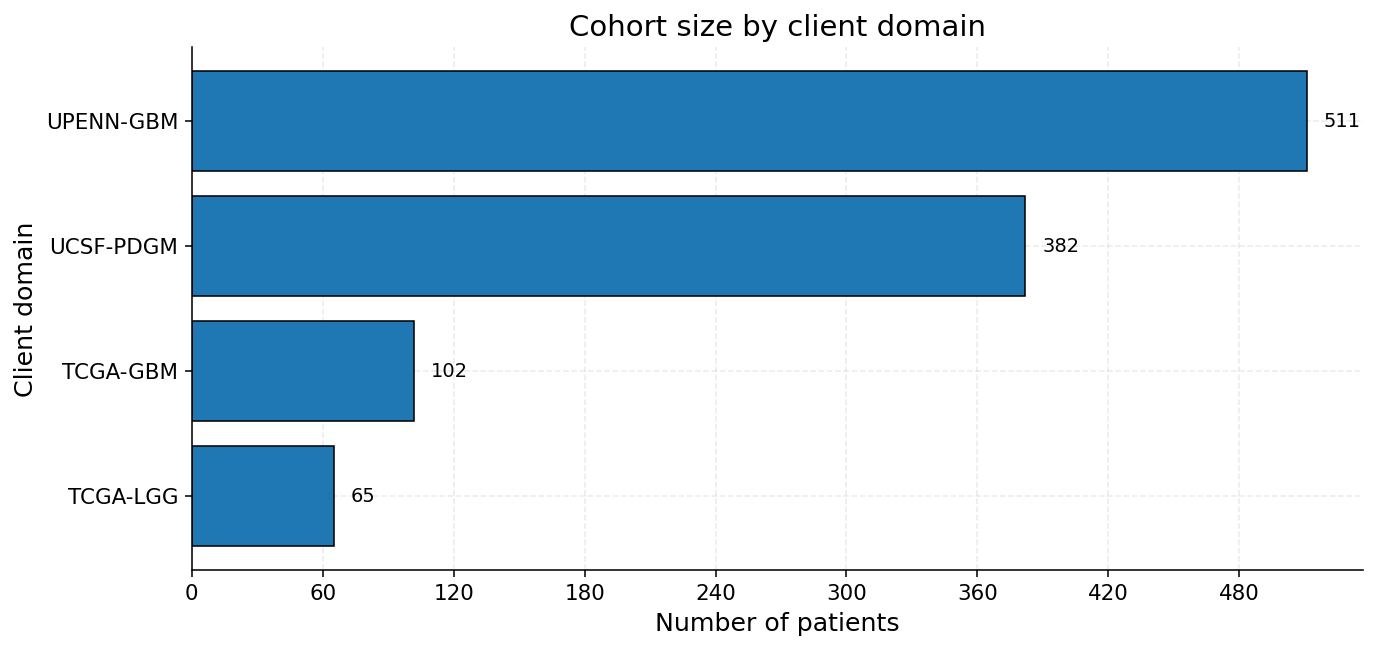

/tmp/ipykernel_29558/3767206835.py:166: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_29558/3767206835.py:166: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_29558/3767206835.py:166: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


Saved: /home/mandrakedrink/projects/research_ts_bs/docs/figures/figure_tumor_burden_boxplots.png
Saved: /home/mandrakedrink/projects/research_ts_bs/docs/figures/figure_tumor_burden_boxplots.pdf


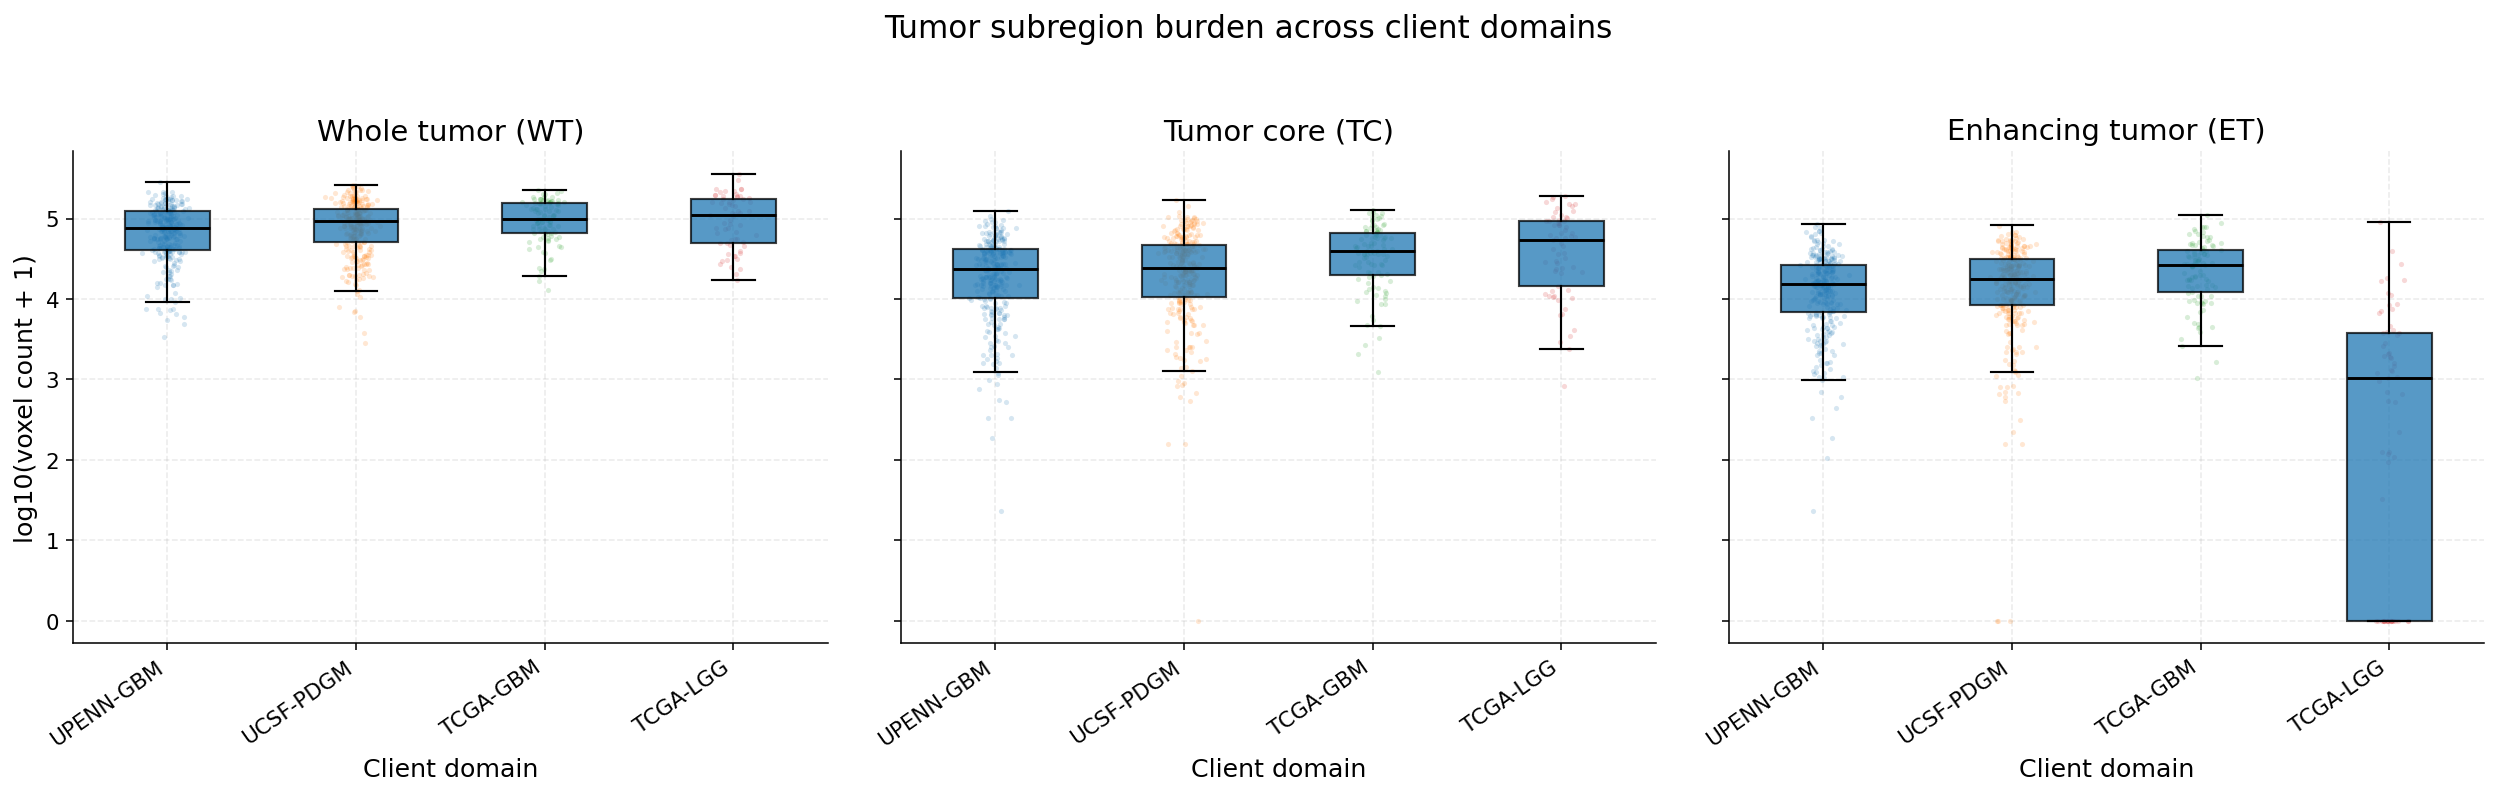

In [24]:
# Publication figures

plot_domain_sizes(
    st_plot,
    domain_order,
    save_name="figure_domain_sizes",
)

plot_tumor_burden_boxplots(
    st_plot,
    domain_order,
    save_name="figure_tumor_burden_boxplots",
)